<a href="https://colab.research.google.com/github/functionykx/CS5228/blob/main/data_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS5228, 2025/26-2, Mini Project


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [80]:
drive.mount('/content/drive')
train_df = pd.read_csv(
    '/content/drive/MyDrive/CS5228/churn-bigml-80.csv',
    header=0,
    skipinitialspace=True
)

test_df = pd.read_csv(
    '/content/drive/MyDrive/CS5228/churn-bigml-20.csv',
    header=0,
    skipinitialspace=True
)

print(f"train set size: {train_df.shape}")
train_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train set size: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


Missing value statistics:
 State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


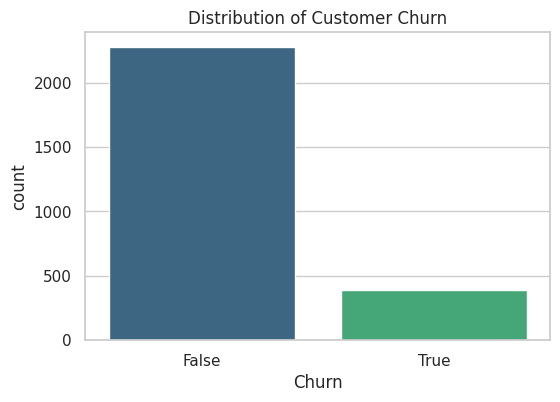

Current Churn Rate: 14.55%


In [81]:
print("Missing value statistics:\n", train_df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train_df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.show()

churn_val_counts = train_df['Churn'].value_counts(normalize=True)
print(f"Current Churn Rate: {churn_val_counts.iloc[1]*100:.2f}%")

In [82]:
binary_cols = ['International plan', 'Voice mail plan', 'Churn']
le = LabelEncoder()

for col in binary_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# State 特征处理
print(f"Number of States: {train_df['State'].nunique()}")
train_df['State_Code'] = le.fit_transform(train_df['State'])
test_df['State_Code'] = le.transform(test_df['State'])

Number of States: 51


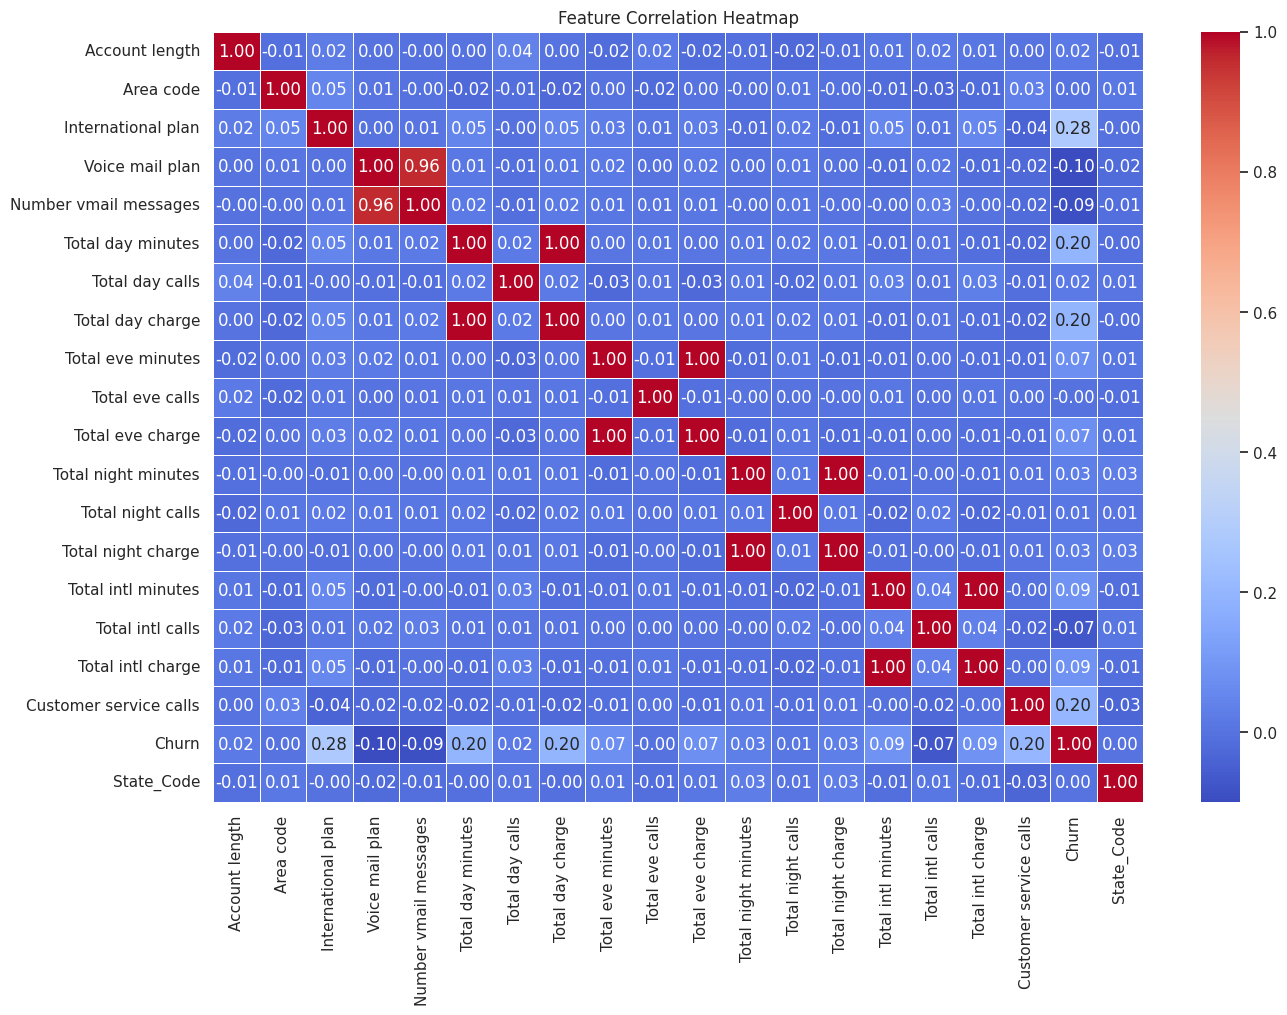

Recommended redundant features to be removed (high collinearity): ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']


In [83]:
corr_matrix = train_df.corr(numeric_only=True)

# heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

redundant_features = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
print("Recommended redundant features to be removed (high collinearity):", redundant_features)

# reduce redundant features
train_df_reduced = train_df.drop(columns=redundant_features + ['State']).copy()
test_df_reduced = test_df.drop(columns=redundant_features + ['State']).copy()

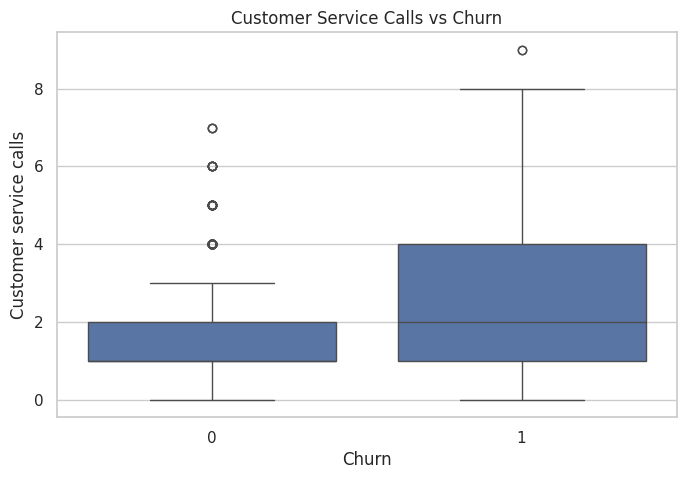

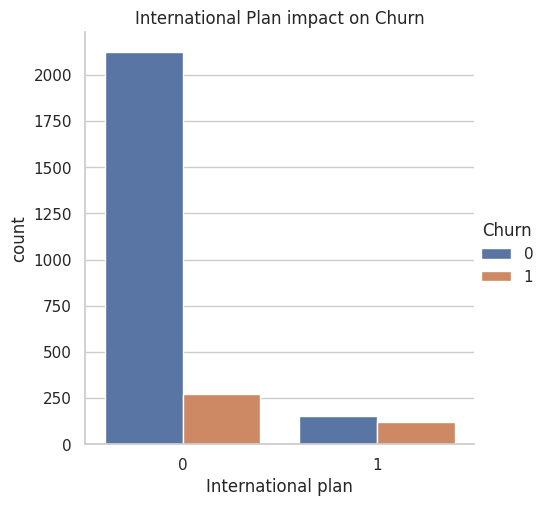

Rank of Features' Correlation with Churn Status:
International plan        0.277489
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
State_Code                0.000430
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Voice mail plan          -0.099291
Name: Churn, dtype: float64


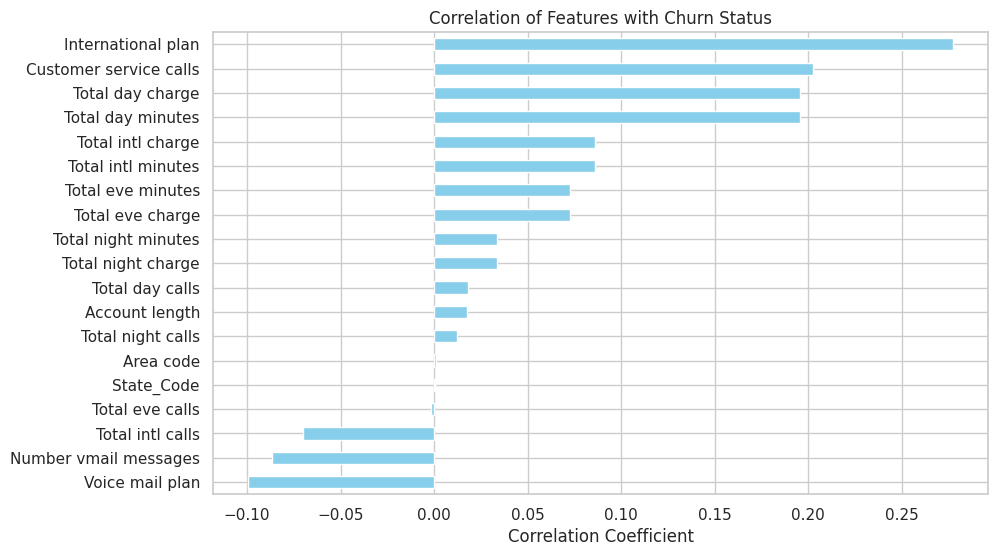

In [84]:
# 1. 客服电话次数与流失的关系
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Customer service calls', data=train_df)
plt.title('Customer Service Calls vs Churn')
plt.show()

# 2. 国际计划的影响
sns.catplot(x="International plan", hue="Churn", kind="count", data=train_df)
plt.title('International Plan impact on Churn')
plt.show()

# 3. 找出与 Churn 相关性最高的特征
top_corr = corr_matrix['Churn'].sort_values(ascending=False)[1:]

print("Rank of Features' Correlation with Churn Status:")
print(top_corr)

plt.figure(figsize=(10, 6))
top_corr.plot(kind='barh', color='skyblue')
plt.title('Correlation of Features with Churn Status')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()
plt.show()

In [85]:
num_cols = train_df_reduced.columns.drop(['Churn', 'International plan', 'Voice mail plan'])
scaler = StandardScaler()
train_df_reduced[num_cols] = scaler.fit_transform(train_df_reduced[num_cols])
test_df_reduced[num_cols] = scaler.transform(test_df_reduced[num_cols])

print("Preprocessing complete! The data is ready for clustering and classification.")

Preprocessing complete! The data is ready for clustering and classification.
